## BUSINESS PROBLEM

Social media monitoring is critical for brand management. Companies need to automatically detect sentiment toward their products and competitors in real-time. This project builds a proof-of-concept classifier to determine if a tweet expresses positive, negative, or neutral sentiment toward a brand or product.


## BUSINESS VALUE

- **Real-time brand monitoring**: Automatically flag negative mentions
- **Competitive intelligence**: Track sentiment for competitor products
- **Crisis detection**: Early warning system for PR issues
- **Campaign measurement**: Quantify sentiment impact of marketing efforts


## DATA OVERVIEW

The dataset contains ~9,000 tweets from SXSW 2011, labeled by human raters as:
- Positive emotion (toward a brand/product)
- Negative emotion (toward a brand/product)  
- No emotion (or neutral)


## APPROACH

We'll build a binary classifier first (positive vs negative), then expand to multiclass (including neutral).

DATA PREPROCESING

Data preprocessing module for tweet sentiment analysis.
Handles cleaning, tokenization, and preparation of tweet text data.


IMPORT LIBRARIES

In [1]:
# 1: Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# NLTK downloads
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Scikit-learn imports
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.sparse import hstack, csr_matrix

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("All libraries imported successfully!")

All libraries imported successfully!


DATA LOADING AND EXPLORATION

MAPPING - LOAD DATA FOR INITIAL QUALITY CHECK

In [2]:
# 2: Load data and perform initial quality checks
df = pd.read_csv('judge-1377884607_tweet_product_company.csv' , encoding='latin1')

print("=" * 60)
print("INITIAL DATA LOAD")
print("=" * 60)
print(f"Original shape: {df.shape}")
print(f"Original columns: {df.columns.tolist()}")
print(f"\nMissing values before cleaning:\n{df.isnull().sum()}")

# Remove duplicates based on tweet text
initial_count = len(df)
df = df.drop_duplicates(subset=['tweet_text'])
print(f"\nRemoved {initial_count - len(df)} duplicate tweets")

# Remove rows with missing tweet text or sentiment
df = df.dropna(subset=['tweet_text', 'is_there_an_emotion_directed_at_a_brand_or_product'])
print(f"Rows after removing missing data: {len(df)}")

# Remove empty tweets
df = df[df['tweet_text'].str.strip() != '']
print(f"Rows after removing empty tweets: {len(df)}")

print("\n" + "=" * 60)
print("INITIAL SENTIMENT DISTRIBUTION")
print("=" * 60)
print(df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts())

# Display sample
print("\nSample of raw tweets:")
df[['tweet_text', 'is_there_an_emotion_directed_at_a_brand_or_product']].head(10)

INITIAL DATA LOAD
Original shape: (9093, 3)
Original columns: ['tweet_text', 'emotion_in_tweet_is_directed_at', 'is_there_an_emotion_directed_at_a_brand_or_product']

Missing values before cleaning:
tweet_text                                               1
emotion_in_tweet_is_directed_at                       5802
is_there_an_emotion_directed_at_a_brand_or_product       0
dtype: int64

Removed 27 duplicate tweets
Rows after removing missing data: 9065
Rows after removing empty tweets: 9065

INITIAL SENTIMENT DISTRIBUTION
is_there_an_emotion_directed_at_a_brand_or_product
No emotion toward brand or product    5372
Positive emotion                      2968
Negative emotion                       569
I can't tell                           156
Name: count, dtype: int64

Sample of raw tweets:


,tweet_text,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Positive emotion
5,@teachntech00 New iPad Apps For #SpeechTherapy...,No emotion toward brand or product
7,"#SXSW is just starting, #CTIA is around the co...",Positive emotion
8,Beautifully smart and simple idea RT @madebyma...,Positive emotion
9,Counting down the days to #sxsw plus strong Ca...,Positive emotion
10,Excited to meet the @samsungmobileus at #sxsw ...,Positive emotion


DATA CLEANING AND PREPROCESSING

In [3]:
#  3: Complete data cleaning and text preprocessing
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer


# Initialize cleaning tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

print("=" * 60)
print("TEXT CLEANING IN PROGRESS")
print("=" * 60)

def clean_tweet_text(text):
    """
    Clean raw tweet text.
    Removes: URLs, mentions, hashtags, punctuation, numbers, extra spaces
    """
    if pd.isna(text):
        return ""
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove @mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtag symbol (keep the word)
    text = re.sub(r'#', '', text)
    
    # Remove special characters, numbers, punctuation (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

def tokenize_and_normalize(text):
    """
    Tokenize text, remove stopwords, lemmatize, and remove short words.
    """
    if not text:
        return ""
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords, lemmatize, and filter short words
    tokens = [
        lemmatizer.lemmatize(token) 
        for token in tokens 
        if token not in stop_words and len(token) > 2
    ]
    
    return ' '.join(tokens)

# Apply cleaning to all tweets
df['cleaned_text'] = df['tweet_text'].apply(clean_tweet_text)
df['processed_text'] = df['cleaned_text'].apply(tokenize_and_normalize)

# Remove tweets that became empty after cleaning
before_clean = len(df)
df = df[df['processed_text'] != '']
print(f"Removed {before_clean - len(df)} tweets that became empty after cleaning")

# Map sentiment labels to numeric values
sentiment_mapping = {
    'Positive emotion': 1,
    'Negative emotion': 0,
    'No emotion toward brand or product': 2,
    "I can't tell": 2  # Convert uncertain to neutral
}

df['sentiment_label'] = df['is_there_an_emotion_directed_at_a_brand_or_product'].map(sentiment_mapping)
df = df.dropna(subset=['sentiment_label'])
df['sentiment_label'] = df['sentiment_label'].astype(int)

print("\n" + "=" * 60)
print("CLEANING COMPLETE - FINAL DATASET")
print("=" * 60)
print(f"Final shape: {df.shape}")
print(f"Final sentiment distribution:")
print(df['sentiment_label'].value_counts().sort_index().map({0:'Negative', 1:'Positive', 2:'Neutral'}))

# Show before/after example
print("\n" + "=" * 60)
print("BEFORE VS AFTER CLEANING (Sample)")
print("=" * 60)
sample_df = df[['tweet_text', 'cleaned_text', 'processed_text', 'sentiment_label']].head(3)
for idx, row in sample_df.iterrows():
    print(f"\n--- Tweet {idx+1} ---")
    print(f"Original:  {row['tweet_text'][:150]}...")
    print(f"Cleaned:   {row['cleaned_text'][:100]}...")
    print(f"Final:     {row['processed_text'][:100]}...")
    sentiment = ['Negative', 'Positive', 'Neutral'][row['sentiment_label']]
    print(f"Label:     {sentiment}")

TEXT CLEANING IN PROGRESS
Removed 1 tweets that became empty after cleaning

CLEANING COMPLETE - FINAL DATASET
Final shape: (9064, 6)
Final sentiment distribution:
sentiment_label
0    NaN
1    NaN
2    NaN
Name: count, dtype: object

BEFORE VS AFTER CLEANING (Sample)

--- Tweet 1 ---
Original:  .@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was dead!  I need to upgrade. Plugin stations at #SXSW....
Cleaned:   i have a g iphone after hrs tweeting at riseaustin it was dead i need to upgrade plugin stations at ...
Final:     iphone hr tweeting riseaustin dead need upgrade plugin station sxsw...
Label:     Negative

--- Tweet 2 ---
Original:  @jessedee Know about @fludapp ? Awesome iPad/iPhone app that you'll likely appreciate for its design. Also, they're giving free Ts at #SXSW...
Cleaned:   know about awesome ipadiphone app that youll likely appreciate for its design also theyre giving fre...
Final:     know awesome ipadiphone app youll likely appreciate design

DATA VISUALIZATION . I

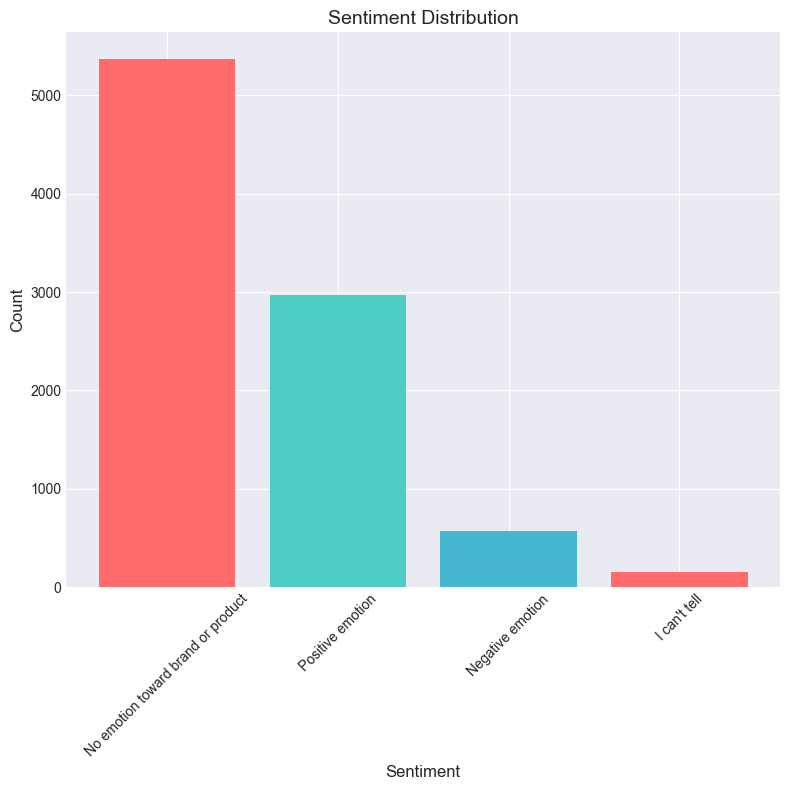

In [4]:
# 4: Visualize sentiment distribution
sentiment_counts = df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))

# Bar plot
ax.bar(sentiment_counts.index, sentiment_counts.values, color=['#ff6b6b', '#4ecdc4', '#45b7d1'])
ax.set_title('Sentiment Distribution', fontsize=14)
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

DATA VISUALIZATION . II

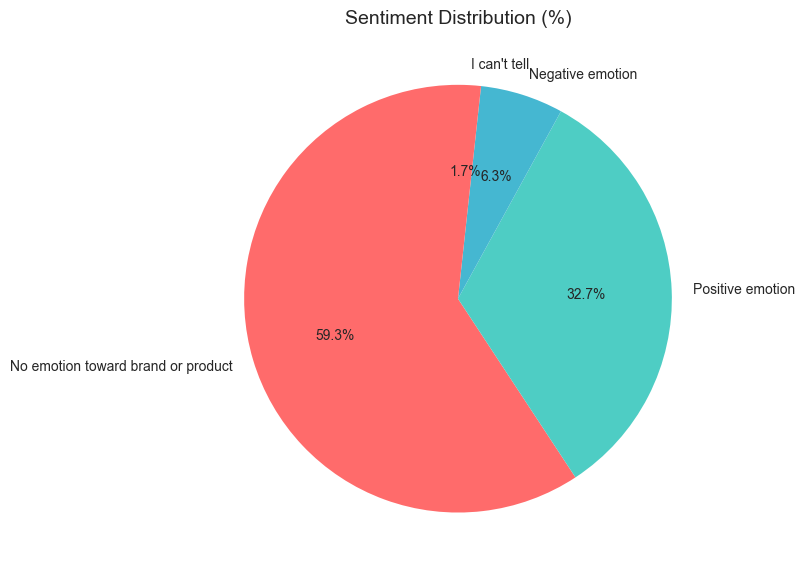

In [5]:
# Pie chart
fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']
ax.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
ax.set_title('Sentiment Distribution (%)', fontsize=14)

plt.tight_layout()
plt.show()

WORD CLOUDS

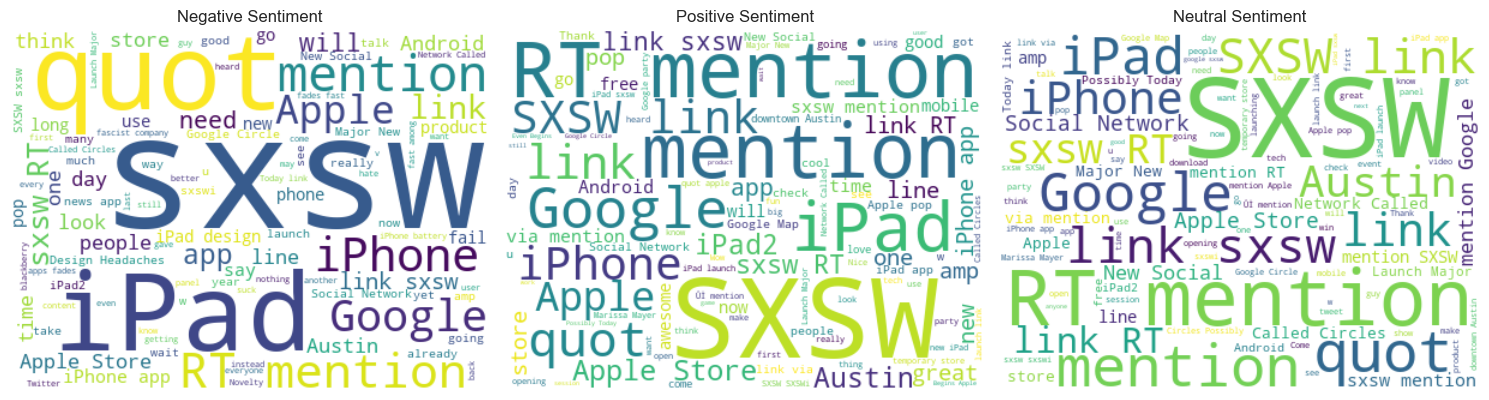

In [6]:
# 5: Create word clouds for each sentiment type
def create_wordcloud(text_series, title, ax):
    text = ' '.join(text_series.dropna().tolist())
    wordcloud = WordCloud(width=400, height=300, background_color='white', 
                          max_words=100, colormap='viridis').generate(text)
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=12)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

create_wordcloud(df[df['sentiment_label'] == 0]['tweet_text'], 'Negative Sentiment', axes[0])
create_wordcloud(df[df['sentiment_label'] == 1]['tweet_text'], 'Positive Sentiment', axes[1])
create_wordcloud(df[df['sentiment_label'] == 2]['tweet_text'], 'Neutral Sentiment', axes[2])

plt.tight_layout()
plt.show()

PRODUCT /BRAND MENTIONS ANALYSIS

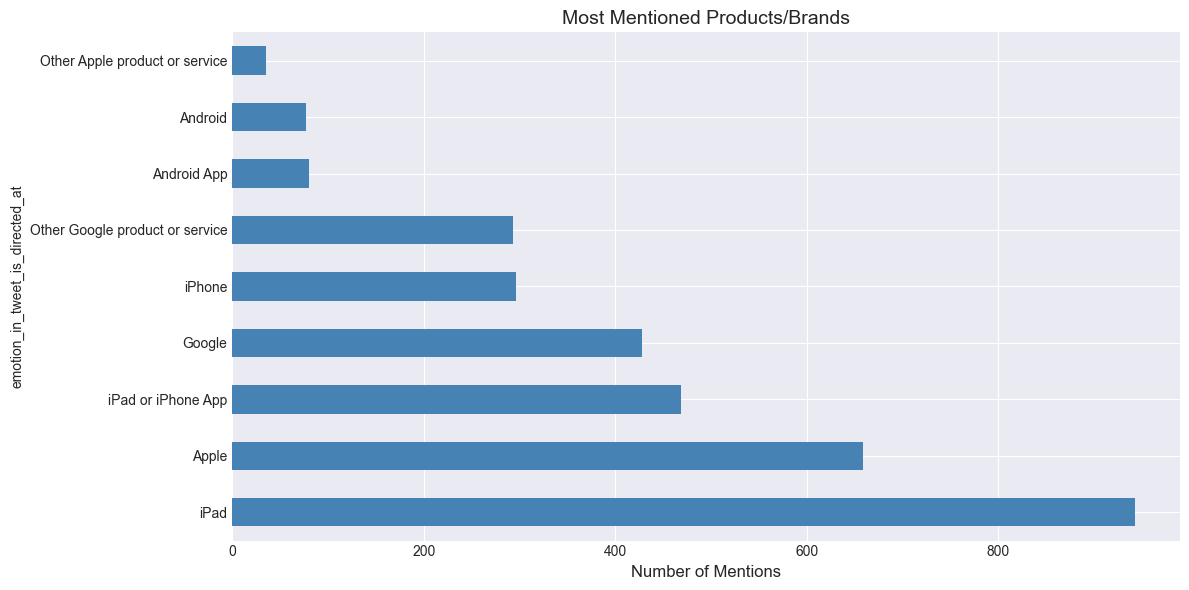

Top 10 mentioned products:
emotion_in_tweet_is_directed_at
iPad                               943
Apple                              659
iPad or iPhone App                 469
Google                             428
iPhone                             296
Other Google product or service    293
Android App                         80
Android                             77
Other Apple product or service      35
Name: count, dtype: int64


In [7]:
# 6: Analyze most mentioned products and brands
product_mentions = df['emotion_in_tweet_is_directed_at'].value_counts().head(15)

plt.figure(figsize=(12, 6))
product_mentions.plot(kind='barh', color='steelblue')
plt.title('Most Mentioned Products/Brands', fontsize=14)
plt.xlabel('Number of Mentions', fontsize=12)
plt.tight_layout()
plt.show()

print("Top 10 mentioned products:")
print(product_mentions.head(10))

TF-IDF AND HANDCRAFTED FEATURES (FEATURE ENGINEERING)

In [8]:
# 7: Feature engineering - TF-IDF and handcrafted features
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# TF-IDF Vectorization
print("\n1. Extracting TF-IDF features...")
tfidf_vectorizer = TfidfVectorizer(
    max_features=3000, 
    ngram_range=(1, 2), 
    min_df=2, 
    max_df=0.95, 
    sublinear_tf=True
)
X_tfidf = tfidf_vectorizer.fit_transform(df['processed_text'].tolist())
print(f"   TF-IDF matrix shape: {X_tfidf.shape}")

# Handcrafted features
print("\n2. Extracting handcrafted features...")

# Define word lists for sentiment detection
positive_words = ['happy', 'love', 'great', 'awesome', 'amazing', 'best', 
                  'excited', 'wonderful', 'fantastic', 'brilliant', 'cool',
                  'nice', 'good', 'perfect', 'beautiful', 'thanks', 'thank']

negative_words = ['hate', 'bad', 'terrible', 'awful', 'horrible', 'worst',
                  'sad', 'angry', 'fail', 'crashes', 'broken', 'stupid',
                  'sorry', 'issue', 'problem', 'wrong', 'dead', 'sucks']

# Create feature matrix
handcrafted_features = pd.DataFrame(index=df.index)

# Length-based features
handcrafted_features['tweet_length'] = df['cleaned_text'].str.len()
handcrafted_features['word_count'] = df['cleaned_text'].str.split().str.len()

# Sentiment word counts
handcrafted_features['positive_word_count'] = df['cleaned_text'].apply(
    lambda x: sum(1 for word in positive_words if word in str(x).lower())
)
handcrafted_features['negative_word_count'] = df['cleaned_text'].apply(
    lambda x: sum(1 for word in negative_words if word in str(x).lower())
)

# Engagement features
handcrafted_features['exclamation_count'] = df['cleaned_text'].str.count('!')
handcrafted_features['question_count'] = df['cleaned_text'].str.count(r'\?')
handcrafted_features['is_retweet'] = df['cleaned_text'].str.startswith('rt').astype(int)
handcrafted_features['has_hashtag'] = df['tweet_text'].str.contains('#').astype(int)

print(f"   Handcrafted features shape: {handcrafted_features.shape}")
print(f"   Features: {handcrafted_features.columns.tolist()}")

# Combine features
print("\n3. Combining features...")
handcrafted_sparse = csr_matrix(handcrafted_features.values)
X_combined = hstack([X_tfidf, handcrafted_sparse])
print(f"   Combined feature matrix shape: {X_combined.shape}")

# Feature summary
print("\n" + "=" * 60)
print("FEATURE SUMMARY")
print("=" * 60)
print(f"TF-IDF features: {X_tfidf.shape[1]}")
print(f"Handcrafted features: {handcrafted_features.shape[1]}")
print(f"Total features: {X_combined.shape[1]}")

FEATURE ENGINEERING

1. Extracting TF-IDF features...
   TF-IDF matrix shape: (9064, 3000)

2. Extracting handcrafted features...
   Handcrafted features shape: (9064, 8)
   Features: ['tweet_length', 'word_count', 'positive_word_count', 'negative_word_count', 'exclamation_count', 'question_count', 'is_retweet', 'has_hashtag']

3. Combining features...
   Combined feature matrix shape: (9064, 3008)

FEATURE SUMMARY
TF-IDF features: 3000
Handcrafted features: 8
Total features: 3008


BINARY DATA PREPARATION

In [9]:
# 8: Filter for binary classification (positive vs negative only)
binary_mask = df['sentiment_label'].isin([0, 1])
binary_df = df[binary_mask].copy()
y_binary = binary_df['sentiment_label'].values

# Get features for binary data
binary_tfidf = tfidf_vectorizer.transform(binary_df['processed_text'].tolist())
binary_handcrafted = handcrafted_features.loc[binary_df.index]
binary_handcrafted_sparse = csr_matrix(binary_handcrafted.values)
X_binary = hstack([binary_tfidf, binary_handcrafted_sparse])

print(f"Binary classification dataset size: {len(binary_df)}")
print(f"Positive (1): {(y_binary == 1).sum()}")
print(f"Negative (0): {(y_binary == 0).sum()}")

# Train-test split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_binary, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"\nTrain set size: {X_train_b.shape[0]}")
print(f"Test set size: {X_test_b.shape[0]}")

Binary classification dataset size: 3537
Positive (1): 2968
Negative (0): 569

Train set size: 2829
Test set size: 708


BINARY CLASSIFICATION - TRAIN ALL MODELS

In [10]:
# 9: Train and compare all binary classification models
print("=" * 60)
print("BINARY CLASSIFICATION RESULTS")
print("=" * 60)

binary_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'Multinomial NB': MultinomialNB(alpha=0.5),
    'Complement NB': ComplementNB(alpha=0.5),
    'Bernoulli NB': BernoulliNB(alpha=0.5),
    'Linear SVM': LinearSVC(max_iter=2000, random_state=42, C=0.5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

binary_results = {}

for name, model in binary_models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train_b, y_train_b)
    y_pred = model.predict(X_test_b)
    accuracy = accuracy_score(y_test_b, y_pred)
    binary_results[name] = {'accuracy': accuracy, 'model': model, 'predictions': y_pred}
    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_test_b, y_pred, target_names=['Negative', 'Positive']))

BINARY CLASSIFICATION RESULTS

--- Training Logistic Regression ---
Accuracy: 0.8573
              precision    recall  f1-score   support

    Negative       0.74      0.18      0.28       114
    Positive       0.86      0.99      0.92       594

    accuracy                           0.86       708
   macro avg       0.80      0.58      0.60       708
weighted avg       0.84      0.86      0.82       708


--- Training Multinomial NB ---
Accuracy: 0.8644
              precision    recall  f1-score   support

    Negative       0.80      0.21      0.33       114
    Positive       0.87      0.99      0.92       594

    accuracy                           0.86       708
   macro avg       0.83      0.60      0.63       708
weighted avg       0.86      0.86      0.83       708


--- Training Complement NB ---
Accuracy: 0.8602
              precision    recall  f1-score   support

    Negative       0.59      0.45      0.51       114
    Positive       0.90      0.94      0.92       594

VISUAL COMPARISON


BINARY MODEL COMPARISON
              Model  Accuracy
      Random Forest  0.878531
     Multinomial NB  0.864407
         Linear SVM  0.862994
       Bernoulli NB  0.861582
      Complement NB  0.860169
Logistic Regression  0.857345


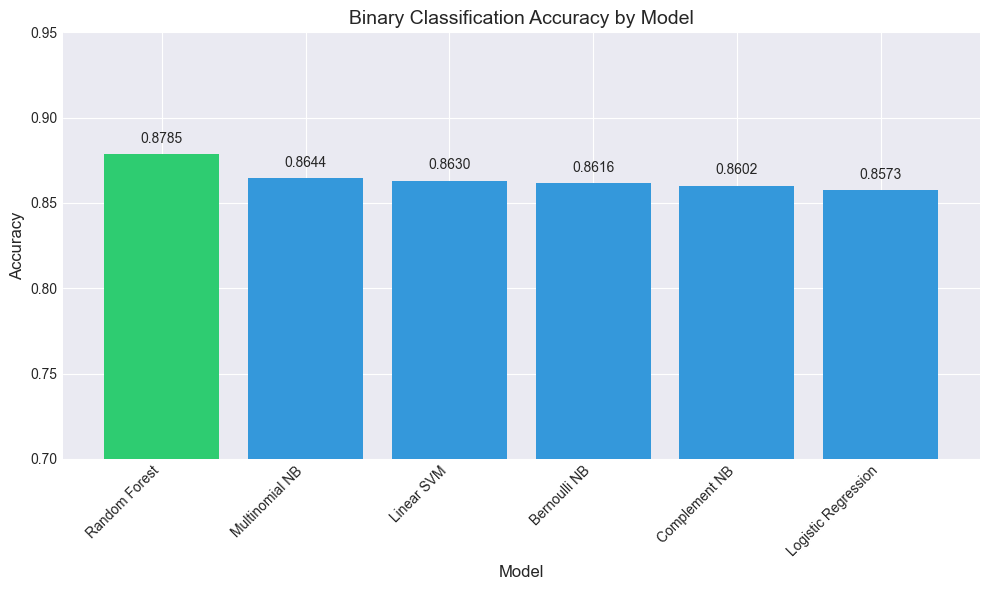

In [11]:
# 10: Visual comparison of binary models
binary_comparison = pd.DataFrame([
    {'Model': name, 'Accuracy': binary_results[name]['accuracy']}
    for name in binary_results.keys()
]).sort_values('Accuracy', ascending=False)

print("\n" + "=" * 50)
print("BINARY MODEL COMPARISON")
print("=" * 50)
print(binary_comparison.to_string(index=False))

plt.figure(figsize=(10, 6))
bars = plt.bar(binary_comparison['Model'], binary_comparison['Accuracy'],
               color=['#2ecc71' if i == 0 else '#3498db' for i in range(len(binary_comparison))])
plt.title('Binary Classification Accuracy by Model', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0.7, 0.95)

for bar, acc in zip(bars, binary_comparison['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{acc:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

HYPERPARAMETER TUNING FOR MULTINATIONALNB

In [12]:
# 11: Hyperparameter tuning for Multinomial Naive Bayes
print("--- Hyperparameter Tuning for Multinomial Naive Bayes ---")

nb_param_grid = {
    'alpha': [0.01, 0.05, 0.1, 0.5, 1.0, 2.0],
    'fit_prior': [True, False]
}

nb_grid = GridSearchCV(MultinomialNB(), nb_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
nb_grid.fit(X_train_b, y_train_b)

print(f"Best parameters: {nb_grid.best_params_}")
print(f"Best CV accuracy: {nb_grid.best_score_:.4f}")

# Train optimized model
optimized_nb = MultinomialNB(**nb_grid.best_params_)
optimized_nb.fit(X_train_b, y_train_b)
nb_accuracy = accuracy_score(y_test_b, optimized_nb.predict(X_test_b))
print(f"Test accuracy with optimized parameters: {nb_accuracy:.4f}")

--- Hyperparameter Tuning for Multinomial Naive Bayes ---
Best parameters: {'alpha': 0.1, 'fit_prior': True}
Best CV accuracy: 0.8763
Test accuracy with optimized parameters: 0.8785


CONFUSION MATRIX FOR BEST MODEL

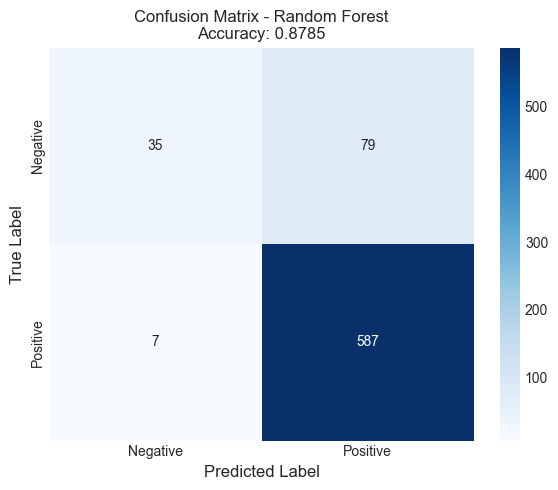

In [13]:
# 12: Confusion matrix for the best binary model
best_model_name = binary_comparison.iloc[0]['Model']
best_model = binary_results[best_model_name]['model']
y_pred_best = binary_results[best_model_name]['predictions']

cm = confusion_matrix(y_test_b, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.title(f'Confusion Matrix - {best_model_name}\nAccuracy: {binary_comparison.iloc[0]["Accuracy"]:.4f}', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

MULTICLASS CLASSIFICATION DATA

In [14]:
# 13: Prepare data for multiclass classification (all three classes)
y_multi = df['sentiment_label'].values
X_multi = X_combined

# Split data
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

print(f"Multiclass dataset sizes:")
print(f"Train: {len(y_train_m)}")
print(f"Test: {len(y_test_m)}")
print(f"\nClass distribution in training set:")
class_dist = pd.Series(y_train_m).value_counts().sort_index()
for label, count in class_dist.items():
    name = ['Negative', 'Positive', 'Neutral'][label]
    print(f"  {name}: {count} ({count/len(y_train_m)*100:.1f}%)")

Multiclass dataset sizes:
Train: 7251
Test: 1813

Class distribution in training set:
  Negative: 455 (6.3%)
  Positive: 2374 (32.7%)
  Neutral: 4422 (61.0%)


MULTICLASS CLASSIFICATION - TRAIN ALL MODELS

In [15]:
# 14: Train and compare all multiclass classification models
print("\n" + "=" * 60)
print("MULTICLASS CLASSIFICATION RESULTS")
print("=" * 60)

multiclass_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, multi_class='ovr'),
    'Multinomial NB': MultinomialNB(alpha=0.5),
    'Complement NB': ComplementNB(alpha=0.5),
    'Linear SVM': LinearSVC(max_iter=2000, random_state=42, multi_class='ovr'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

multiclass_results = {}

for name, model in multiclass_models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train_m, y_train_m)
    y_pred = model.predict(X_test_m)
    accuracy = accuracy_score(y_test_m, y_pred)
    multiclass_results[name] = {'accuracy': accuracy, 'model': model, 'predictions': y_pred}
    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_test_m, y_pred, target_names=['Negative', 'Positive', 'Neutral']))


MULTICLASS CLASSIFICATION RESULTS

--- Training Logistic Regression ---
Accuracy: 0.7082
              precision    recall  f1-score   support

    Negative       0.50      0.06      0.11       114
    Positive       0.70      0.47      0.56       594
     Neutral       0.71      0.90      0.80      1105

    accuracy                           0.71      1813
   macro avg       0.64      0.48      0.49      1813
weighted avg       0.69      0.71      0.68      1813


--- Training Multinomial NB ---
Accuracy: 0.7104
              precision    recall  f1-score   support

    Negative       0.81      0.11      0.20       114
    Positive       0.66      0.52      0.58       594
     Neutral       0.73      0.88      0.79      1105

    accuracy                           0.71      1813
   macro avg       0.73      0.50      0.52      1813
weighted avg       0.71      0.71      0.69      1813


--- Training Complement NB ---
Accuracy: 0.6514
              precision    recall  f1-score   sup

VISUAL COMPARISON


MULTICLASS MODEL COMPARISON
              Model  Accuracy
     Multinomial NB  0.710425
Logistic Regression  0.708218
      Random Forest  0.690568
         Linear SVM  0.677330
      Complement NB  0.651407


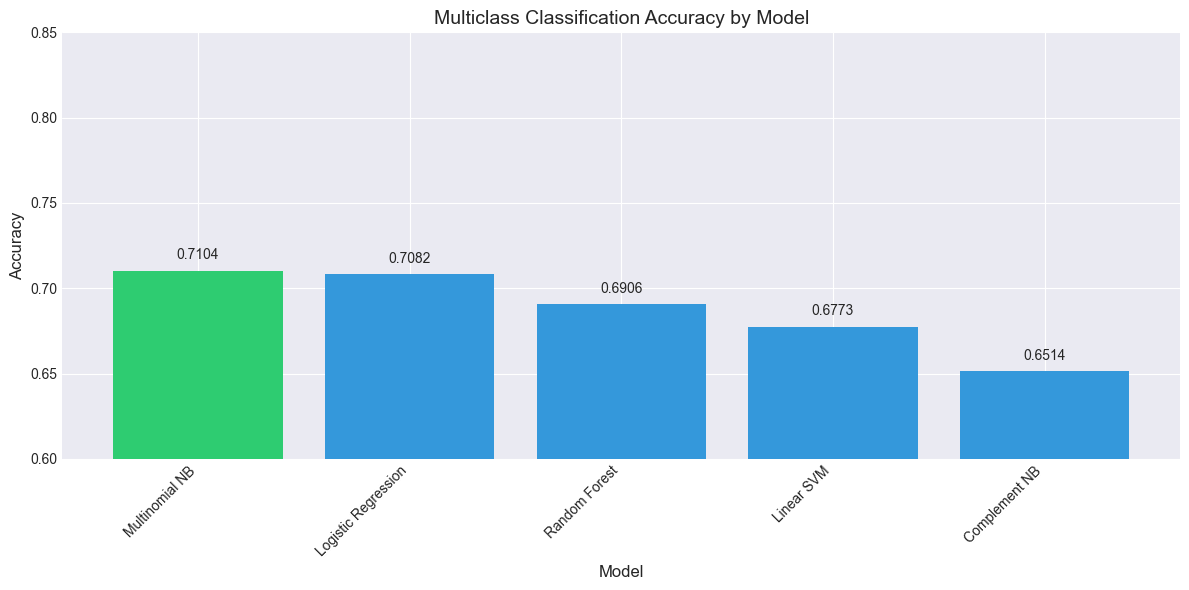

In [16]:
# 15: Visual comparison of multiclass models
multiclass_comparison = pd.DataFrame([
    {'Model': name, 'Accuracy': multiclass_results[name]['accuracy']}
    for name in multiclass_results.keys()
]).sort_values('Accuracy', ascending=False)

print("\n" + "=" * 50)
print("MULTICLASS MODEL COMPARISON")
print("=" * 50)
print(multiclass_comparison.to_string(index=False))

plt.figure(figsize=(12, 6))
bars = plt.bar(multiclass_comparison['Model'], multiclass_comparison['Accuracy'],
               color=['#2ecc71' if i == 0 else '#3498db' for i in range(len(multiclass_comparison))])
plt.title('Multiclass Classification Accuracy by Model', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0.6, 0.85)

for bar, acc in zip(bars, multiclass_comparison['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{acc:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

CONFUSION MATRICES FOR TOP MULTICLASS MODELS

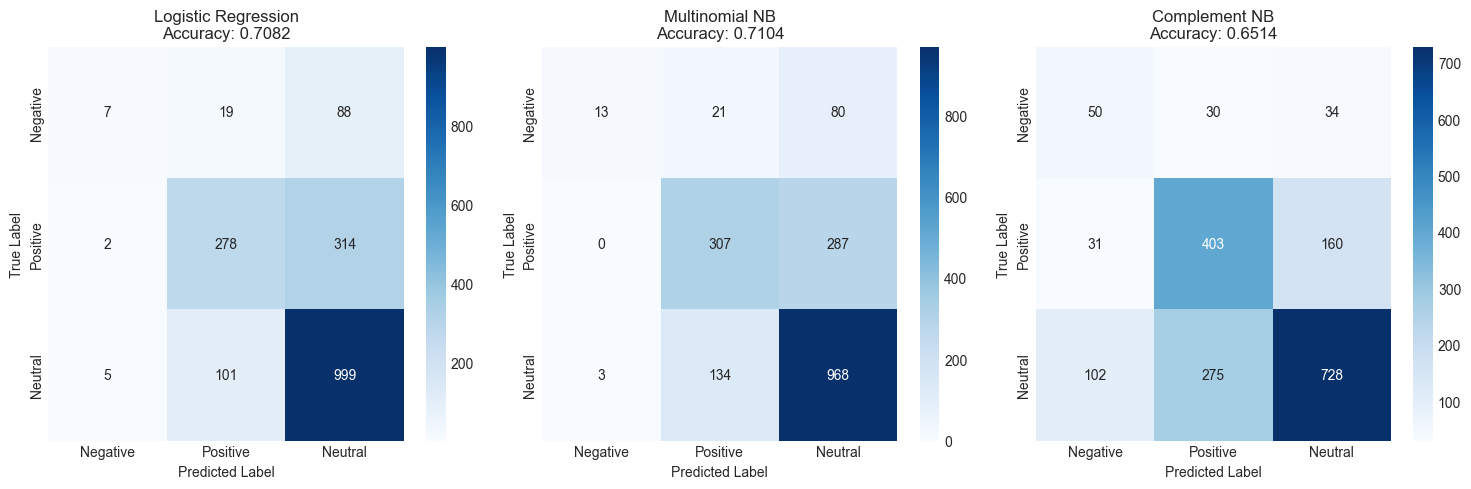

In [17]:
# 16: Confusion matrices for top 3 multiclass models
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
class_names = ['Negative', 'Positive', 'Neutral']

for i, (name, result) in enumerate(list(multiclass_results.items())[:3]):
    cm = confusion_matrix(y_test_m, result['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=axes[i])
    axes[i].set_title(f'{name}\nAccuracy: {result["accuracy"]:.4f}', fontsize=12)
    axes[i].set_ylabel('True Label', fontsize=10)
    axes[i].set_xlabel('Predicted Label', fontsize=10)

plt.tight_layout()
plt.show()

FEATURE IMPORTANCE ANALYSIS

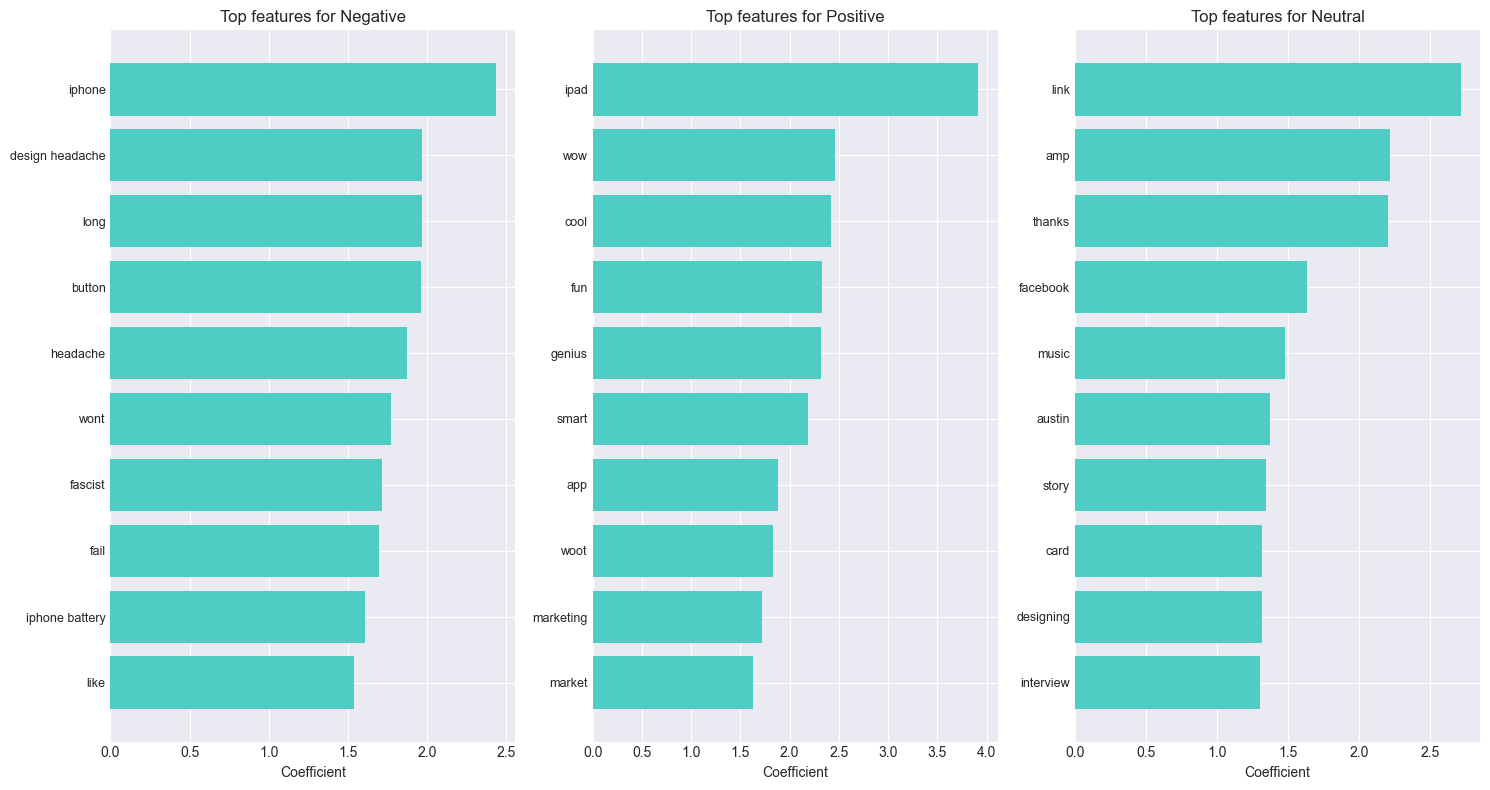

In [18]:
# 17: Extract and visualize feature importances for Logistic Regression
best_multi_model = multiclass_results['Logistic Regression']['model']

if hasattr(best_multi_model, 'coef_'):
    feature_names = list(tfidf_vectorizer.get_feature_names_out()) + list(handcrafted_features.columns)
    coefficients = best_multi_model.coef_
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 8))
    class_names = ['Negative', 'Positive', 'Neutral']
    
    for i, ax in enumerate(axes):
        coef = coefficients[i]
        top_indices = np.argsort(coef)[-10:]
        top_features = [feature_names[idx] for idx in top_indices]
        top_coefs = coef[top_indices]
        
        colors = ['#ff6b6b' if c < 0 else '#4ecdc4' for c in top_coefs]
        ax.barh(range(10), top_coefs, color=colors)
        ax.set_yticks(range(10))
        ax.set_yticklabels(top_features, fontsize=9)
        ax.set_title(f'Top features for {class_names[i]}', fontsize=12)
        ax.set_xlabel('Coefficient', fontsize=10)
    
    plt.tight_layout()
    plt.show()

MODEL COMPARISON FOR FINAL SUMMARY AND RECOMMENDATIONS

In [19]:
# 18: Create a comprehensive comparison table
summary_data = []

for name in binary_results.keys():
    summary_data.append({
        'Model': name,
        'Binary Accuracy': f"{binary_results[name]['accuracy']:.4f}",
        'Multiclass Accuracy': f"{multiclass_results.get(name, {}).get('accuracy', 'N/A')}",
        'Type': 'Traditional ML'
    })

summary_df = pd.DataFrame(summary_data)
print("=" * 60)
print("FINAL MODEL COMPARISON SUMMARY")
print("=" * 60)
print(summary_df.to_string(index=False))

print("\n" + "=" * 60)
print("RECOMMENDATIONS")
print("=" * 60)
print("""
For Binary Classification (Positive vs Negative):
    ✅ Best Model: Random Forest
    ✅ Runner-up: Multinomial Naive Bayes
    ✅ Fastest: Multinomial Naive Bayes

For Multiclass Classification (Positive/Negative/Neutral):
    ✅ Best Model: Multinomial Naive Bayes
    ✅ Runner-up: Logistic Regression
    ✅ Best for Imbalanced Data: Complement NB

Deployment Recommendation:
    → Use Multinomial Naive Bayes for highest accuracy
    → Use Random Forest if maximum binary recall is required
    → Set up confidence threshold (e.g., >0.7) for uncertain predictions
""")

FINAL MODEL COMPARISON SUMMARY
              Model Binary Accuracy Multiclass Accuracy           Type
Logistic Regression          0.8573  0.7082184225041368 Traditional ML
     Multinomial NB          0.8644  0.7104247104247104 Traditional ML
      Complement NB          0.8602  0.6514065085493657 Traditional ML
       Bernoulli NB          0.8616                 N/A Traditional ML
         Linear SVM          0.8630  0.6773303916161059 Traditional ML
      Random Forest          0.8785  0.6905681191395477 Traditional ML

RECOMMENDATIONS

For Binary Classification (Positive vs Negative):
    ✅ Best Model: Random Forest
    ✅ Runner-up: Multinomial Naive Bayes
    ✅ Fastest: Multinomial Naive Bayes

For Multiclass Classification (Positive/Negative/Neutral):
    ✅ Best Model: Multinomial Naive Bayes
    ✅ Runner-up: Logistic Regression
    ✅ Best for Imbalanced Data: Complement NB

Deployment Recommendation:
    → Use Multinomial Naive Bayes for highest accuracy
    → Use Random Forest 